In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad
import pandas as pd

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

# Varryying Kappa

In [7]:
# Simulation parameters
N = 200
sigma = 1.0
rho = 1.0 / (sigma**2)
L = np.sqrt(N / rho)

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 2.5
U_0 = V_0 / kBT

F_D = 150 * kBT / sigma

tau = gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 20.0 * tau
t_prod = 50.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)

In [8]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r, r_cut, kappa):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r, r_cut, kappa):
    if r < 1e-8 or r > r_cut:
        return 0.0
    return V_0 * sigma * np.exp(-kappa * (r - sigma)) * (kappa * r + 1) / r**2

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction AND the external driving
@njit(fastmath=True)
def compute_forces(pos, r_cut, kappa):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r, r_cut, kappa) # Magnitude of the force

            if r < r_cut:

                fx = F_mag * dx / r
                fy = F_mag * dy / r

                # Apply Newton's third law / symmetry of the force matrix:
                forces[i, 0] += fx
                forces[i, 1] += fy

                forces[j, 0] -= fx
                forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step
@njit(fastmath=True)
def bd_step_equil(pos, r_cut, kappa):
    F_matrix = compute_forces(pos, r_cut, kappa)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# Brownian Dynamics integration step with species
@njit(fastmath=True)
def bd_step_drive(pos, species, F_D, r_cut, kappa):
    F_matrix = compute_forces(pos, r_cut, kappa)
    F_matrix[:,0] += species * F_D # external driving force

    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

# g(r) computation
@njit
def compute_gr(pos, r_max, dr):
    n_bins = int(r_max / dr)
    hist = np.zeros(n_bins)

    for i in range(N):
        xi, yi = pos[i]
        for j in range(i+1, N):
            dx = min_image(xi - pos[j,0], L)
            dy = min_image(yi - pos[j,1], L)
            r = np.sqrt(dx*dx + dy*dy)

            if r < r_max:
                bin_idx = int(r / dr)
                hist[bin_idx] += 2.0

    return hist

def write_ovito(filename, pos, species, L, step):
    N = pos.shape[0]
    with open(filename, "a") as f:
        f.write("ITEM: TIMESTEP\n")
        f.write(f"{step}\n")
        f.write("ITEM: NUMBER OF ATOMS\n")
        f.write(f"{N}\n")
        f.write("ITEM: BOX BOUNDS pp pp pp\n")
        f.write(f"0 {L}\n")
        f.write(f"0 {L}\n")
        f.write(f"0 1\n")
        f.write("ITEM: ATOMS id type x y z\n")

        for i in range(N):
            atom_id = i + 1
            atom_type = 1 if species[i] == 1 else 2
            x, y = pos[i]
            f.write(f"{atom_id} {atom_type} {x} {y} 0.0\n")

def create_last_snapshot(pos, species, F_D):
    df = pd.DataFrame(dict(L=pos[:,0], R=pos[:,1], label=species))
    groups = df.groupby('label')

    fig, ax = plt.subplots(figsize=(6, 6))
    for particle, group in groups:
        ax.scatter(group.L, group.R, label=particle)
        ax.legend(bbox_to_anchor=(1, 1))
        ax.set_aspect('equal')
        fig.tight_layout()
        #fig.savefig('last_snapshotF_D_%s.png' % F_D)


def save_dict(pos, species, ):
    saved_var = {'pos' : pos, 'species': species}
    np.save('saved_var.npy',  saved_var) 


# Phi calculation, onset of lane formation
@njit(fastmath=True)
def compute_phi(N, pos, species, L, r_l):
    phi = np.zeros(N)

    for i in range(N):
        yi = pos[i,1]
        fi = species[i]

        isolated = True

        for j in range(N):

            if species[j] == fi:
                continue
            
            dy = yi - pos[j,1]
            dy -= L * np.round(dy/L)

            if abs(dy) < r_l:
                isolated = False
                break

        phi[i] = 1.0 if isolated else 0.0
    return phi.mean()



In [9]:
kappas = np.linspace(0.5,5,10) * sigma
r_cuts = 6.0 / kappas
r_l = 0.5 / np.sqrt(rho)
Phi_t = []

Kappa: 0.5
Running Equilibration...
Progress: 0%
Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Progress: 100%
Measured ⟨v_x⟩ (A) at equilibration: 0.052283849474641056
Measured ⟨v_x⟩ (B) at equilibration: -0.05019587716543073
Running Brownian Dynamics simulation...
Progress: 0%
Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Progress: 100%
Simulation finished.
Measured ⟨v_x⟩ (A): 148.9670444399387
Measured ⟨v_x⟩ (B): -148.96305409982676
Theory F_D/γ: 150.0




Kappa: 1.0
Running Equilibration...
Progress: 0%
Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Progress: 100%
Measured ⟨v_x⟩ (A) at equilibration: 0.0413735959466381
Measured ⟨v_x⟩ (B) at equilibration: 0.00346102655587399
Running Brownian Dynamics simulation...
Progress: 0%
Progress: 10%
Progres

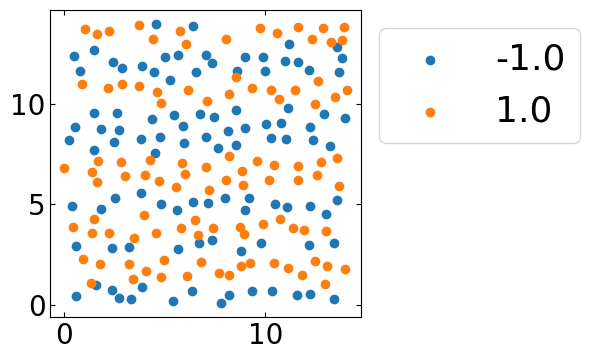

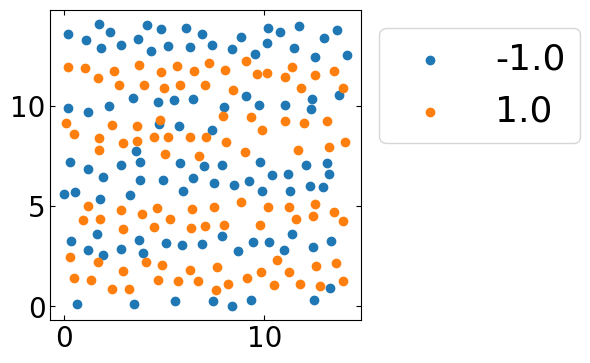

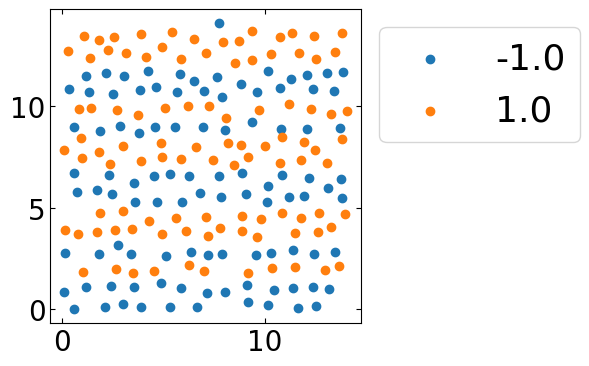

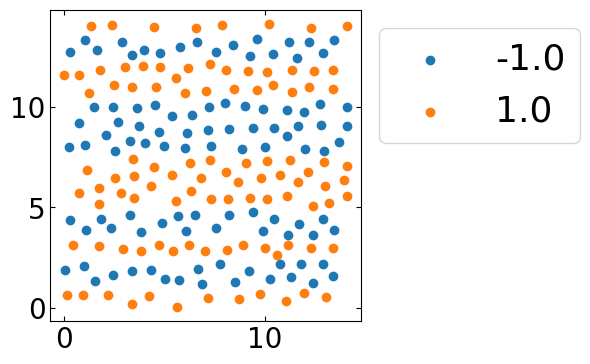

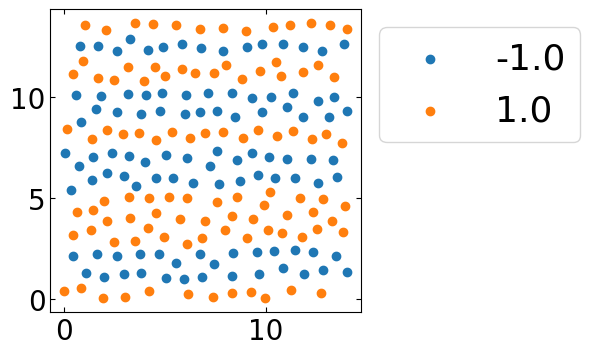

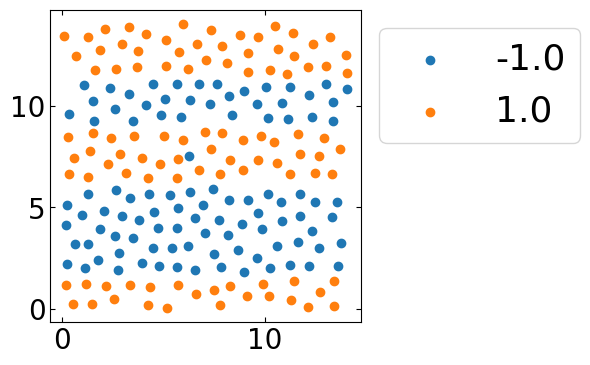

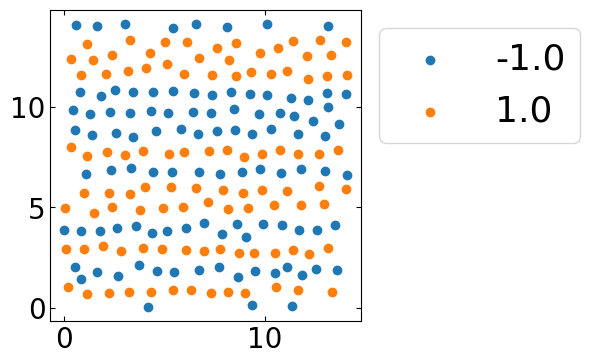

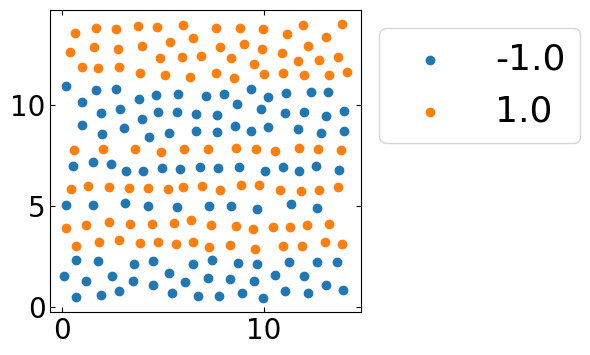

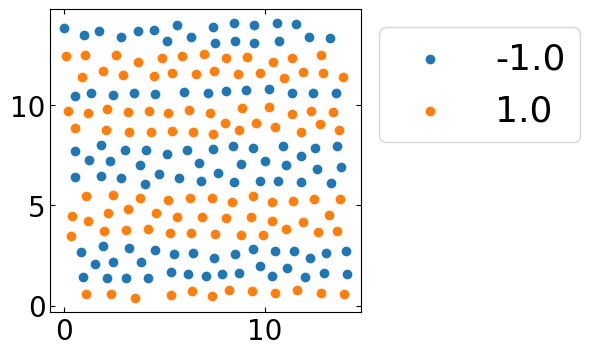

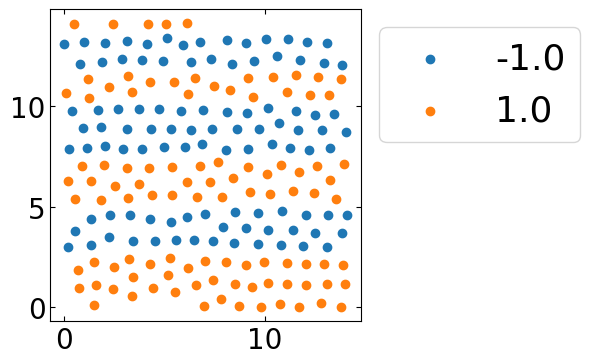

In [10]:
# Main simulation
text_file = open("task5_result.txt", "w")

for index in range(len(kappas)):
        print("Kappa: %s" % kappas[index].item())
        text_file.write("Summary Kappa: %s\n" % kappas[index].item())
        pos = init_grid(L, N)
        pos0 = pos.copy()

        # Species labels f_i = ±1
        species = np.ones(N)
        species[:N // 2] = -1
        np.random.shuffle(species)

        vx_A = []
        vx_B = []

        print("Running Equilibration...")
        # Equilibration
        for step in range(n_steps_equil):
               pos_old = pos.copy()
               pos = bd_step_equil(pos, r_cuts[index].item(), kappas[index].item())
               
               dx = pos[:,0] - pos_old[:,0]
               dx = min_image(dx, L)
               vx = dx/dt
               
               vx_A.append(np.mean(vx[species == 1]))
               vx_B.append(np.mean(vx[species == -1]))
               
               if step % (n_steps_equil // 10) == 0:
                      print(f"Progress: {100 * step / n_steps_equil:.0f}%")
                      
        vA = np.mean(vx_A)
        vB = np.mean(vx_B)
        
        print("Measured ⟨v_x⟩ (A) at equilibration:", vA)
        text_file.write("Measured ⟨v_x⟩ (A) at equilibration: %s\n" % vA)
        print("Measured ⟨v_x⟩ (B) at equilibration:", vB)
        text_file.write("Measured ⟨v_x⟩ (B) at equilibration: %s\n" % vB)
        print("Running Brownian Dynamics simulation...")
        
        # Ovito
        #dumpfile = "task5_F_D_%s.dump" % F_D
        #open(dumpfile, "w").close()
        
        vx_A = []
        vx_B = []
        
        for step in range(n_steps_prod):
                pos_old = pos.copy()
                pos = bd_step_drive(pos, species, F_D, r_cuts[index].item(), kappas[index].item())
                
                dx = pos[:,0] - pos_old[:,0]
                dx = min_image(dx, L)
                vx = dx/dt
                
                vx_A.append(np.mean(vx[species == 1]))
                vx_B.append(np.mean(vx[species == -1]))
                
                if step % (n_steps_prod // 10) == 0:
                        print(f"Progress: {100 * step / n_steps_prod:.0f}%")



                        
                #if step % 10 == 0:
                #        write_ovito(dumpfile, pos, species, L, step)
                        
        print("Simulation finished.")
                
        vA = np.mean(vx_A)
        vB = np.mean(vx_B)
        
        Phi = compute_phi(N, pos, species, L, r_l)
        Phi_t.append(Phi)
        
        print("Measured ⟨v_x⟩ (A):", vA)
        text_file.write("Measured ⟨v_x⟩ (A): %s\n" % vA)
        print("Measured ⟨v_x⟩ (B):", vB)
        text_file.write("Measured ⟨v_x⟩ (B): %s\n" % vB)
        print("Theory F_D/γ:", F_D / gamma)
        theo_v = F_D/gamma
        text_file.write("Theory F_D/γ: %s\n\n\n" % theo_v)
        print("")
        print("")
        print("")
        print("")
        
        create_last_snapshot(pos, species, F_D)

text_file.close()

/var/folders/rm/s0k967k97p1dxnwxvw2t85vc0000gn/T/ipykernel_1702/261491372.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


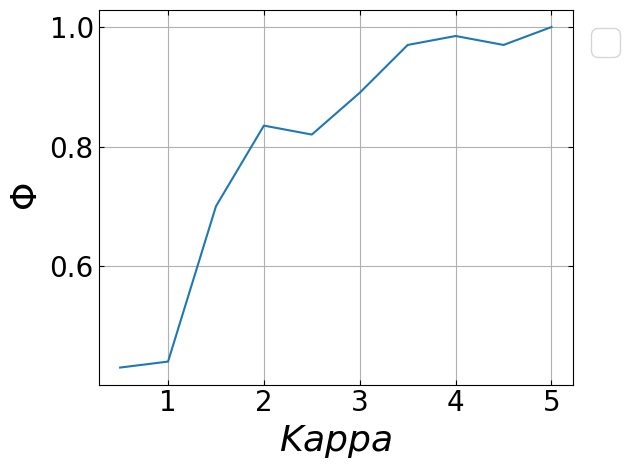

In [11]:
plt.plot(kappas, Phi_t)
plt.xlabel(r"$Kappa$")
plt.ylabel(r"$\Phi$")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.grid()

In [ ]:
# try for different densities